### 0. 데이터 로딩
- ex02에서 저장한 actor별 action pickle 파일들을 불러와서 병합

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX Project

/content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX Project


In [3]:
import pandas as pd
import numpy as np
import ast

# ex02에서 저장한 pickle 파일 수 (actor 수와 동일)
NUM_ACTORS = 2  # ← cluster_sbert의 고유값 수로 변경

df_list = []
for i in range(1,NUM_ACTORS):
    df_list.append(pd.read_pickle(f"./data/cluster_df_{i}_action.pkl"))

print(f"{len(df_list)}개 actor 파일 로딩 완료")

1개 actor 파일 로딩 완료


In [4]:
# 하나의 데이터프레임으로 병합
df = pd.concat(df_list, axis=0)
df.reset_index(drop=True, inplace=True)

print("병합 후 shape:", df.shape)
df.head()

병합 후 shape: (18118, 6)


,doc_idx,text,tokens,tokens_str,cluster_sbert,action_cluster
0,0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데.....","[자유, 다방, 신축, 아파트, 옵션, 신축, 아파트, 옵션, 고르, 시스템, 에어...",자유 다방 신축 아파트 옵션 신축 아파트 옵션 고르 시스템 에어컨 바닥 생각 고민 ...,1,2
1,1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...,"[자유, 게시판, 아파트, 옵션, 확인, 주변, 정도, 아파트, 단지, 고객, 설명...",자유 게시판 아파트 옵션 확인 주변 정도 아파트 단지 고객 설명 자료 만들 아파트 ...,1,2
2,2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...,"[자유, 게시판, 아파트, 에어컨, 옵션, 관련, 안녕, 미혼, 결혼, 예정, 아파...",자유 게시판 아파트 에어컨 옵션 관련 안녕 미혼 결혼 예정 아파트 거주 목적 입주 ...,1,2
3,3,자유게시판아파트 옵션 중도대출 받을때 옵션을 선택한다고 하는데 입주시에 입주자들과 ...,"[자유, 게시판, 아파트, 옵션, 중도, 대출, 옵션, 선택, 입주, 입주자, 에어...",자유 게시판 아파트 옵션 중도 대출 옵션 선택 입주 입주자 에어 오븐 옵션,1,2
4,4,고민상담신축아파트 조명 옵션 안녕하세요 청약 당첨돼서 내일 옵션계약하러갑니다 근데 ...,"[고민, 상담, 신축, 아파트, 조명, 옵션, 안녕, 청약, 당첨, 내일, 옵션계약...",고민 상담 신축 아파트 조명 옵션 안녕 청약 당첨 내일 옵션계약 조명 옵션 모르 사...,1,2


In [5]:
# tokens 컬럼이 문자열인 경우 리스트로 변환
if isinstance(df['tokens'].iloc[0], str):
    df['tokens'] = df['tokens'].apply(ast.literal_eval)

# actor 컬럼명 통일 (cluster_sbert → cluster)
if 'cluster_sbert' in df.columns and 'cluster' not in df.columns:
    df = df.rename(columns={'cluster_sbert': 'cluster'})

print("컬럼 목록:", df.columns.tolist())
df.head()

컬럼 목록: ['doc_idx', 'text', 'tokens', 'tokens_str', 'cluster', 'action_cluster']


,doc_idx,text,tokens,tokens_str,cluster,action_cluster
0,0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데.....","[자유, 다방, 신축, 아파트, 옵션, 신축, 아파트, 옵션, 고르, 시스템, 에어...",자유 다방 신축 아파트 옵션 신축 아파트 옵션 고르 시스템 에어컨 바닥 생각 고민 ...,1,2
1,1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...,"[자유, 게시판, 아파트, 옵션, 확인, 주변, 정도, 아파트, 단지, 고객, 설명...",자유 게시판 아파트 옵션 확인 주변 정도 아파트 단지 고객 설명 자료 만들 아파트 ...,1,2
2,2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...,"[자유, 게시판, 아파트, 에어컨, 옵션, 관련, 안녕, 미혼, 결혼, 예정, 아파...",자유 게시판 아파트 에어컨 옵션 관련 안녕 미혼 결혼 예정 아파트 거주 목적 입주 ...,1,2
3,3,자유게시판아파트 옵션 중도대출 받을때 옵션을 선택한다고 하는데 입주시에 입주자들과 ...,"[자유, 게시판, 아파트, 옵션, 중도, 대출, 옵션, 선택, 입주, 입주자, 에어...",자유 게시판 아파트 옵션 중도 대출 옵션 선택 입주 입주자 에어 오븐 옵션,1,2
4,4,고민상담신축아파트 조명 옵션 안녕하세요 청약 당첨돼서 내일 옵션계약하러갑니다 근데 ...,"[고민, 상담, 신축, 아파트, 조명, 옵션, 안녕, 청약, 당첨, 내일, 옵션계약...",고민 상담 신축 아파트 조명 옵션 안녕 청약 당첨 내일 옵션계약 조명 옵션 모르 사...,1,2


### 1. Satisfaction (만족도)
- HuggingFace `monologg/koelectra-base-finetuned-sentiment` 모델로 감성분석
- KNU 감성사전 방식(단어 매칭)과 달리 **문장 전체 문맥**을 이해하여 긍정/부정 분류
- 긍정 확률(0~1)을 감성점수로 사용 → 0~10으로 정규화

#### 1.1 KoELECTRA 모델 로딩
- 모델: `monologg/koelectra-base-finetuned-sentiment`
- 라벨: `positive`(긍정) / `negative`(부정)
- 입력: 원문 텍스트(`text` 컬럼) — 토큰이 아닌 원문 문장 사용
- 512 토큰 초과 시 자동 truncation 처리

In [6]:
!pip install transformers torch -q

In [7]:
from transformers import pipeline

MODEL_NAME = "monologg/koelectra-base-finetuned-sentiment"

# GPU 사용 가능 여부 자동 감지
import torch
device = 0 if torch.cuda.is_available() else -1
print("사용 디바이스:", "GPU" if device == 0 else "CPU")

sentiment_pipeline = pipeline(
    "text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=device
)

# 동작 테스트
print("긍정 테스트:", sentiment_pipeline("오늘 정말 기분이 좋아요!"))
print("부정 테스트:", sentiment_pipeline("너무 힘들고 지쳐서 못하겠어요."))

사용 디바이스: GPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/441M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/441M [00:00<?, ?B/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-base-finetuned-sentiment
Key                        | Status     | 
---------------------------+------------+-
classifier.weight          | UNEXPECTED | 
classifier.bias            | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

긍정 테스트: [{'label': 'positive', 'score': 0.514818012714386}]
부정 테스트: [{'label': 'negative', 'score': 0.5440280437469482}]


#### 1.2 전체 문서 감성분석 (배치 처리)
- `text` 컬럼(원문 문장)을 모델에 입력
- 배치 처리로 속도 향상

In [8]:
from tqdm import tqdm

BATCH_SIZE = 32  # ← GPU 메모리에 따라 조절 (CPU면 16~32 권장)

texts = df['text'].fillna('').tolist()
raw_results = []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="감성분석 진행중"):
    batch = texts[i:i + BATCH_SIZE]
    results = sentiment_pipeline(
        batch,
        truncation=True,
        max_length=512
    )
    raw_results.extend(results)

print(f"\n분석 완료: {len(raw_results)}건")
print("결과 샘플:", raw_results[:3])

감성분석 진행중: 100%|██████████| 567/567 [04:45<00:00,  1.98it/s]


분석 완료: 18118건
결과 샘플: [{'label': 'negative', 'score': 0.541742205619812}, {'label': 'negative', 'score': 0.5278270244598389}, {'label': 'negative', 'score': 0.5364913940429688}]


#### 1.3 긍정 확률을 감성점수로 변환
- `positive` 라벨이면 score 그대로 사용
- `negative` 라벨이면 `1 - score`로 변환
- 결과: 0(완전 부정) ~ 1(완전 긍정)

In [9]:
def extract_positive_score(result):
    """모델 출력에서 긍정 확률 추출"""
    label = result['label'].lower()
    score = result['score']
    if label in ('positive', '1', 'pos'):
        return score
    else:  # negative, 0, neg
        return 1 - score

sentiment_scores = [extract_positive_score(r) for r in raw_results]

df['sentiment_score'] = sentiment_scores

print("감성점수 기초 통계 (긍정 확률 0~1):")
print(df['sentiment_score'].describe())
df[['text', 'cluster', 'action_cluster', 'sentiment_score']].head(10)

감성점수 기초 통계 (긍정 확률 0~1):
count    18118.000000
mean         0.467946
std          0.016957
min          0.422708
25%          0.454461
50%          0.464236
75%          0.480371
max          0.536524
Name: sentiment_score, dtype: float64


,text,cluster,action_cluster,sentiment_score
0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데.....",1,2,0.458258
1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...,1,2,0.472173
2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...,1,2,0.463509
3,자유게시판아파트 옵션 중도대출 받을때 옵션을 선택한다고 하는데 입주시에 입주자들과 ...,1,2,0.458491
4,고민상담신축아파트 조명 옵션 안녕하세요 청약 당첨돼서 내일 옵션계약하러갑니다 근데 ...,1,2,0.453594
5,"마창진부동산수다방아파트 외관 디자인 vs 실내 옵션, 어디에 돈 쓰는 게 나을까요?...",1,1,0.475839
6,인테리어 질문아파트 옵션 선택 D20 조언 부탁드립니다 곧 옵션 선택을 해야하는데 ...,1,2,0.454358
7,울산맘 수다공간신축아파트옵션 아파트 분양받아서 이제 유상옵션?신청하라고 해서 고르는...,1,2,0.475554
8,N잡 부수입 수다방분양권매매 생애2번째 아파트옵션 계약하러갑니다 다들 축하해주세요!...,1,3,0.452446
9,인테리어 질문신축아파트옵션 도와주세요 이제곧 옵션 선택하는 날이 다가오네요시스템에어...,1,2,0.458590


#### 1.4 Actor별 Action 감성점수 집계 (평균)

In [10]:
action_sentiments = {}

for actor in sorted(df['cluster'].unique()):
    actor_df = df[df['cluster'] == actor]
    for action in sorted(actor_df['action_cluster'].unique()):
        action_df = actor_df[actor_df['action_cluster'] == action]
        action_sentiment_avg = np.mean(action_df['sentiment_score'])
        key = f"Actor{actor}_Action{action}"
        action_sentiments[key] = action_sentiment_avg
        print(f"  {key}: {action_sentiment_avg:.4f} ({len(action_df)}건)")

print("\n집계 완료")

  Actor1_Action1: 0.4712 (3249건)
  Actor1_Action2: 0.4652 (11804건)
  Actor1_Action3: 0.4701 (2066건)
  Actor1_Action4: 0.4856 (999건)

집계 완료


#### 1.5 감성점수 정규화 (0~10 스케일링)

In [11]:
!pip install new_value_analysis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.6 MB/s eta 0:00:00


In [12]:
from new_value_analysis.opportunity_area_analysis import minmax_scale_scores

scaled_scores = minmax_scale_scores(action_sentiments, feature_range=(0, 10))

for key, score in zip(action_sentiments.keys(), scaled_scores):
    action_sentiments[key] = score

print("정규화 후 감성점수 (0~10):")
action_sentiments

정규화 후 감성점수 (0~10):


{'Actor1_Action1': 2.9643,
 'Actor1_Action2': 0.0,
 'Actor1_Action3': 2.4228,
 'Actor1_Action4': 10.0}

In [21]:
# 만족도 데이터프레임 생성 및 저장
satisfaction_df = pd.DataFrame(action_sentiments.items(), columns=['Action', 'satisfaction'])
satisfaction_df.to_pickle('./data/satisfaction_df.pkl')
print("저장 완료: satisfaction_df.pkl")
satisfaction_df

저장 완료: satisfaction_df.pkl


,Action,satisfaction
0,Actor1_Action1,2.9643
1,Actor1_Action2,0.0000
2,Actor1_Action3,2.4228
3,Actor1_Action4,10.0000


### 2. Importance (중요도)
- 문서 언급 빈도 기반으로 중요도 측정
- 1~10 범위로 정규화

In [15]:
# 각 문서에 Actor_Action 라벨 부여
actor_action_labels = [
    f"Actor{actor}_Action{action}"
    for actor, action in zip(df['cluster'], df['action_cluster'])
]

s = pd.Series(actor_action_labels)
total_count = s.shape[0]

importances = s.value_counts() / total_count
print("Actor-Action별 언급 비율:")
importances

Actor-Action별 언급 비율:


,count
Actor1_Action2,0.651507
Actor1_Action1,0.179324
Actor1_Action3,0.114030
Actor1_Action4,0.055139


In [16]:
scaled_importances = minmax_scale_scores(importances, feature_range=(1, 10))

importance_df = importances.reset_index()
importance_df.columns = ['Action', 'count_ratio']
importance_df['importance'] = scaled_importances

print("정규화 후 중요도 (1~10):")
importance_df

정규화 후 중요도 (1~10):


,Action,count_ratio,importance
0,Actor1_Action2,0.651507,10.0000
1,Actor1_Action1,0.179324,2.8741
2,Actor1_Action3,0.114030,1.8888
3,Actor1_Action4,0.055139,1.0000


### 3. 만족도 + 중요도 병합 및 Opportunity Score
- 공식: `중요도 + max(중요도 - 만족도, 0)`

In [17]:
satisfaction_df = satisfaction_df.set_index('Action')
importance_df = importance_df.set_index('Action')

satisfaction_df['importance'] = importance_df['importance']
DCX_summary = satisfaction_df.copy()

print("DCX Summary:")
DCX_summary

DCX Summary:


,satisfaction,importance
Action,,
Actor1_Action1,2.9643,2.8741
Actor1_Action2,0.0000,10.0000
Actor1_Action3,2.4228,1.8888
Actor1_Action4,10.0000,1.0000


In [22]:
def opportunity_score(sat, imp):
    """기회점수 = 중요도 + max(중요도 - 만족도, 0)"""
    return imp + max(imp - sat, 0)

DCX_summary['opportunity'] = [
    opportunity_score(s, i)
    for s, i in zip(DCX_summary['satisfaction'], DCX_summary['importance'])
]

DCX_summary.to_csv('./data/opportunity.csv')
print("저장 완료: opportunity.csv")
DCX_summary

저장 완료: opportunity.csv


,Action,satisfaction,importance,opportunity
0,Actor1_Action1,2.9643,2.8741,2.8741
1,Actor1_Action2,0.0000,10.0000,20.0000
2,Actor1_Action3,2.4228,1.8888,1.8888
3,Actor1_Action4,10.0000,1.0000,1.0000


### 4. 기회영역 시각화

In [19]:
from new_value_analysis.opportunity_area_analysis import plot_opportunity_area, OpportunityPlotConfig

DCX_summary = DCX_summary.reset_index()
print("컬럼 목록:", DCX_summary.columns.tolist())

컬럼 목록: ['Action', 'satisfaction', 'importance', 'opportunity']


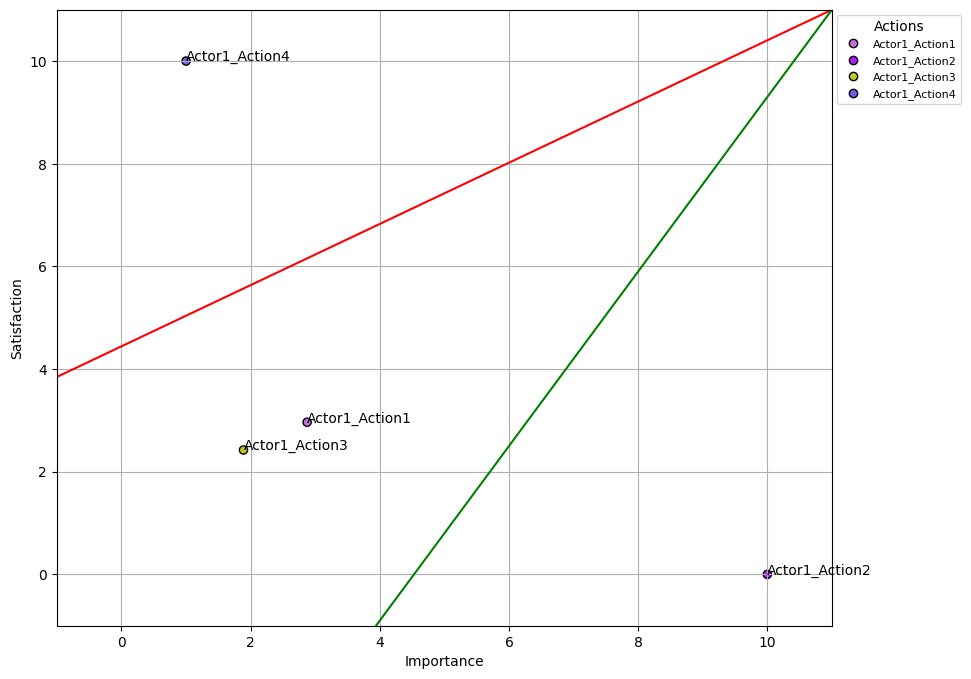

시각화 저장 완료: Opportunity_area.png


In [23]:
cfg = OpportunityPlotConfig(save_path='./data/Opportunity_area.png',random_seed=42,xlim=(-1,11),ylim=(-1,11))

plot_opportunity_area(DCX_summary.dropna(), cfg)
print("시각화 저장 완료: Opportunity_area.png")